<a href="https://colab.research.google.com/github/HuBiZuk/AI_Study/blob/main/08_01_%ED%95%A9%EC%84%B1%EA%B3%B1%EC%8B%A0%EA%B2%BD%EB%A7%9D_%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 합성곱 신경망의 전체 구조

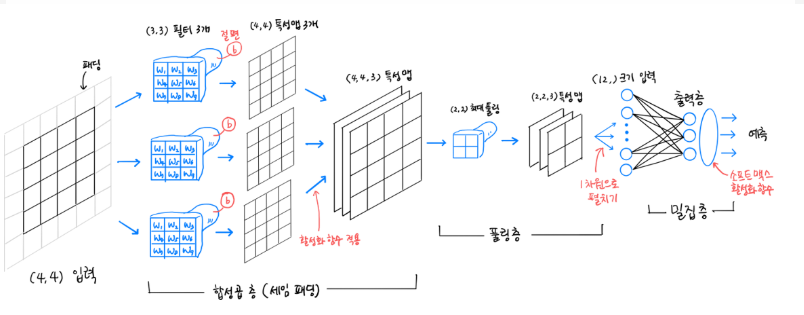

In [ ]:
# 최대 풀링은 가장 큰 값을 고르기 때문에 첫번째 9, 두번째 7, 세번째 8, 네번째 6을 차례대로 골라
# (2,2) 크기의 출력을 만듬.

# 특성 맵이 여러개라면 동일한 작업을 반복함 (10개의 특성 맵이 있다면 풀링을 거친 특성 맵도 10개)
# 풀링 영역이 두칸씩 이동을 함 -> 겹침 없이 이동(합성 곱에서 커널이 한칸씩 이동했기 때문에
#                                 겹치는 부분이 있었다.)
# 풀링 크기가 (2,2)면 2칸씩 이동, (3,3)이면 3칸씩 이동

# 풀링은 가중치가 없고 풀링 크기와 스트라이드가 같기 때문에 이해하기 쉽다. (패딩도 없다)
# keras.layers.MaxPooling2D(2) # 대부분 풀링의 크기는 2 (가로 세로 크기를 절반으로 줄임)

# 합성곱 층과 마찬가지로 strides와 padding 매개변수를 제공함
# strides의 기본값은 자동으로 풀링의 크기이므로 따로 지정 하지 않음
# padding의 기본값은 valid로 패딩을 하지 않음

# keras.layers.MaxPooling2D(2, strides=2, padding="same") # 최대 풀링 코드
# 대부분 최대 풀링을 많이 사용한다.

# keras.layers.AveragePooling2D(2, strides=2, padding="valid") # 평균 풀링 코드
# 평균풀링은 특성 맵에 있는 중요한 정보를 평균을 내어 희석시킬 수 있기 때문

# keypoint : 풀링은 가로 세로 방향만 진행한다.(특성 맵의 개수는 변하지 않고 그대로)

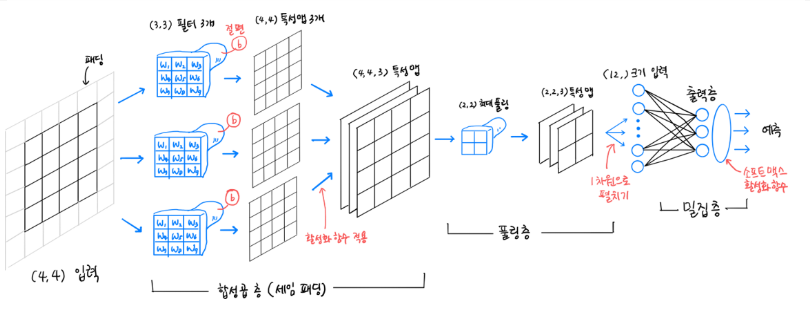

In [ ]:
# 1. (4,4) 입력값에 패딩 1을 적용
# 2. 합성곱 에서 사용할 커널의 크기는 (3,3) 크기이고 세임 패딩이 1이므로 1픽셀이 입력 데이터 주변에 추가
# 3. 이때 패딩은 텐서 플로에서 자동으로 추가하므로 수동으로 입력에 어떤 작업을 추가할 필요가 없음
# 4. 패딩이 추가된 입력에서 합성곱이 수행됨

# 5. 합성곱의 필터는 3개임 (각각 3,3 크기의 가중치를 가지고 있으며 필터마다 절편이 하나씩 있음)
# 6. 밀집층의 뉴런과 마찬가지로 필터의 가중치는 각기 서로 다름, 합성곱의 스트라이드는 항상 1
# 7. 만들어지는 특성 맵의 크기는 입력과 동일한 (4,4), 3개의 필터가 하나씩 합성곱의 출력을 만들고
#    이 출력이 합쳐져서 (4,4,3)크기의 특성맵 생성
# 8. 밀집층과 마찬가지로 합성곱 층에서도 활성화 함수를 적용함(합성곱의 활성화 함수로 렐루사용)

# 9. 풀링층은 합성곱 층에서 만든 특성 맵의 가로세로 크기를 줄입
# 10. 보통 (2,2) 풀링을 사용해서 절반으로 줄임 (특성 맵의 개수는 변하지 않음 (2,2,3))
# 10-1. 풀링을 사용함년 합성곱에서 스트라이드를 크게하여 특성 맵을 줄이는 것보다
#       풀링 층에서 크기를 줄이는 것이 더 나은 성능임

# 11. 밀집층인 출력층에서 전달하려면 3차원 배열을 1차원 배열로 펼쳐야 함(Flatten 클래스)
#     -> 12개의 원소를 가진 1차원 배열이고 출력층의 입력이 됨
# 12. 3개의 뉴런을 두었고 (3개의 클래스를 분류하는 다중분류
#     -> 출력층에서 계산된 값은 소프트맥스 활성화 함수를 거침) -> 최종 예측 확률이 됨ㅁ

In [ ]:
# 컬러 이미지인 경우 !
# 컬러인 경우에는 RGB(빨, 녹, 파) 체널로 구현되어 있음
# 하나의 컬러 이미지는 너비와 높이 차원 이외에 깊이 차원 (채널 차원)이 있다. (4,4,3)이 되는것!
# -> 마지막 3이 깇이

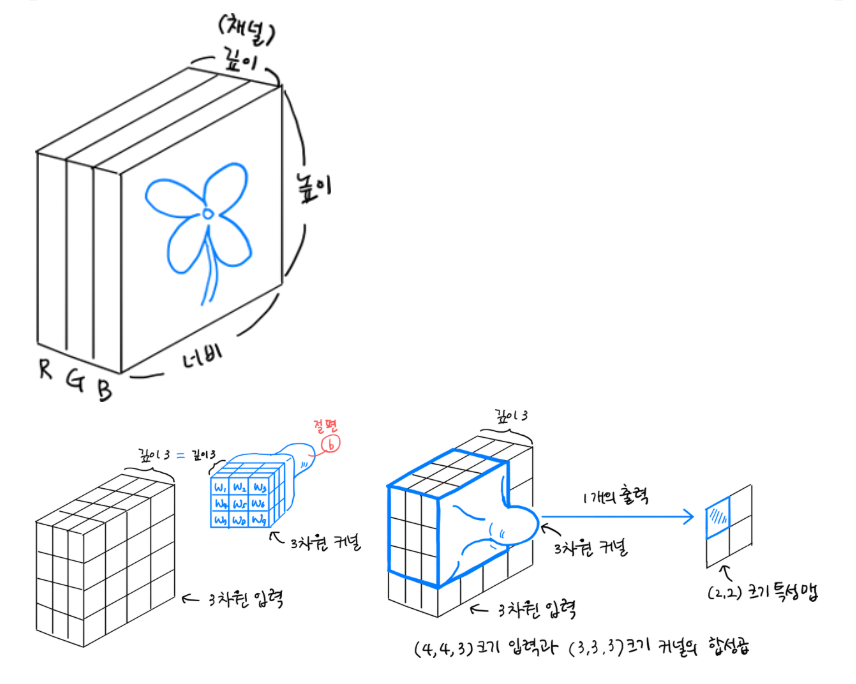

In [ ]:
# 깊이가 있는 입력에서 합성곱을 수행하기 위해서는 도장도 깊이가 필요합니다.
# 즉 커널의 크기가(3,3)이 아니라 (3,3,3)이 됨

# 커널 배열의 깊이는 항상 입력 깊이와 같다.
# 합성곱의 계산은(3,3,3) 영엳에 해당하는 27개의 원소에 27개의 가중치를 곱하고 절편을 더하는 식
# 기본적으로 2차원 합성곱과 같지만 조장이 입력의 깊이만큼 쑥 들어간다고 생각해봄
# 결론은 입력이나 필터의 차원이 몇개인지 상관없이 항상 출력은 하나의 값(특성 맵에 있는 한 원소가 채워짐)

# 케라스의 합성곱 층은 원래 3차원 입력을 준비한다.
#(우리가 흑백이미진인 MNIST를 예제로 사용해서 그렇지 원래는 모두 컬러)
# (28,28,1) 크기의 3차원 배열로 변환(원소 개수는 동일하면서 차원만 맞춤)

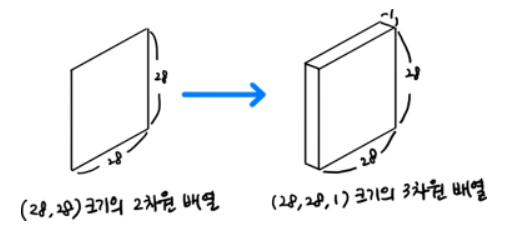

In [ ]:
# 이와 비슷한 경우는 합성곱 층-풀링 층 다음에 다시 또 합성곱 층이 올때
# 첫번째 합성곱 층의 필터 개수가 5개 라고 가정하여
# 첫 번째 풀링 층을 통과한 특성맵의 크기가 (4,4,5)라고 했을 때
# 두번째 합성곱 층에서 필터의 너비와 높이가 각각 3 이라면 이 필터의 커널 크기는 (3,3,5)가 됨
# 이유 : 입력의 깊이와 필터의 깊이는 같아야함(3*3*5=45 개의 가중치를 곱하고 절편을 더함)
#     -> 합성곱의 결과는 1개의 출력

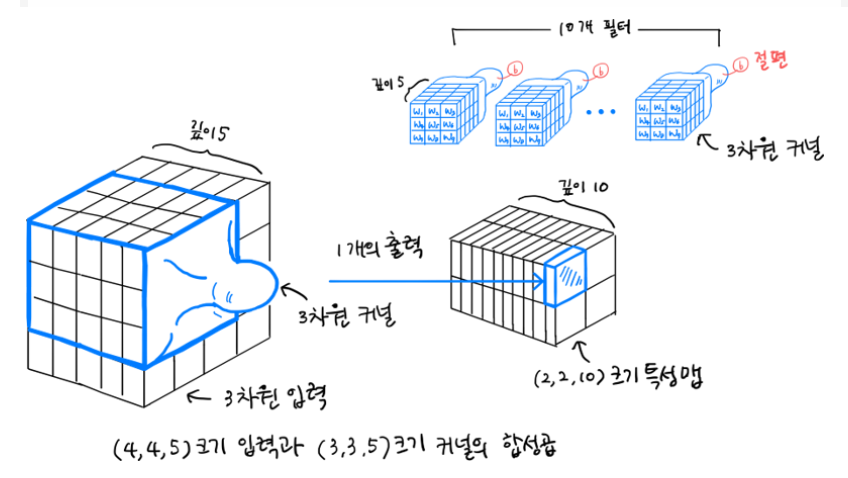

In [ ]:
# 두 번째 합성곱 층의 필터 개수가 10 개라면 만들어진 특성 맵의 크기는 (2,2,10)이 됨
# 이렇게 합성곱 신경망은 너비와 높이는 점점 줄어들고 깊이는 점점 깊어지는 것이 특징
# 마지막에 출력층 전에 특성 맵을 모두 펼쳐서 밀집층의 입력으로 사용

# 합성곱 신경망 에서 필터는 이미지에 있는 어떤 특징을 찾는다
# 처음에는 간단한 기본적인 특징(직선, 곡선 등)을 찾고 층이
# 깊어질 수록 다양하고 구체적인 특징을 감지할수 있도록 필터의 개수를 늘림

# 또 어떤 특징이 이미지의 어느 위치에 놓이더라도 쉽게 감지할수 있도록 너비와 높이 차원을
# 점점 줄여가는 것이 합성곱 신경망의 목효임
###################CNN 이론 끝 ========================================

In [ ]:
# 합성곱 신경망을 사용한 이미지 분류 실습

# 전에 배운 합성곱, 필터, 스트라이드, 풀링 등은 직접 계산할 필요가 없다.
# 케라스 API 가 알아서 한다. 그러나 개념과 돌아가는 기능에 대한 느낌을 알아야 최적의 결과를 얻을 수 있다.
# 그래서 동작 원리를 터득하고 특히 다른 신경망 구조를 만나도 잘 적응할 수 있다.

# 패션 MNIST를 활용하여 응용 해본다.
# 전처리: 데이터 스케일을 0~255 사이에서 0~1 사이로 바꾸고 훈련 세트와 검증 세트로 나눔
# 차이점은 완전 연결 신경망에서는 입력 이미지를 밀집층에 연결하기 위해 일렬로 펼쳐야 한다.
# (넘파이 reshape(), Flatten 사용) 합성곱 신경망은 2차원 이미지를 그대로 사용하기 때문에 할 필요가 없다.
# 입력 이미지는 항상 깊이(채널) 차원이 있어야함

# 흑백 이미지의 경우 채널 차원이 없는 2차원 배열이지만 Conv2D 층을 사용하기 위해
# 마지막에 이 채널 차원을 추가해야함
# 넘파이 reshpae() 메서드를 이용해 전체 배열 차원을 그대로 유지하면서 마지막에 차원을 간단히 추가함

In [ ]:
import tensorflow as tf
# 실행마다 동일한 결과를 얻기 위해 케라스에 랜덤 시드를 사용하고 텐서플로 연산을 결정적으로 만듬

tf.keras.utils.set_random_seed(42)

from tensorflow import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data() # 패션 MIST 데이터 불러오기

train_scaled = train_input.reshape(-1,28,28,1) /1255.0
# train_input(48000,28,28)-> train_scaled(48000,28,28,1)로 4차원 변경 됨(마지막 차원은 흑백이라 1)

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state = 42)
# 훈련 데이터, 검증 데이터, 훈련타겟, 검증타겟 -> 8:2

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 합성곱 신경망 만들기 : 합성곱 층으로 이미지에서 특징을 감지한 후
# 밀집층으로 클래스에 따른 분류 확률을 계산함

model = keras.Sequential() # Sequential 클래스의 객체를 만듬
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same', input_shape=(28,28,1)))
# Conv2D 층을 add로 추가
# 32 합성곱 층으로 32개의 필터를 사용
# kernel_size=3 : 커널의 크기는 (3,3)
# activation='relu' : 렐루 활성화 함수 사용
# padding='same' : 세임 패딩 사용
# input_shape=(28,28,1) : 앞에 변경한 이미지를 차원 변경함
# 결론: 28 * 28 * 32의 출력 -> 풀링으로 압축(14 * 14* 32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


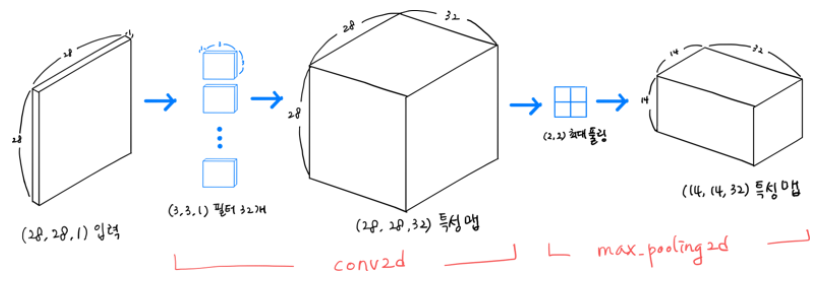

In [ ]:
model.add(keras.layers.MaxPooling2D(2))
# 풀링 층 추가(최대 풀링(1:1) 특성 맵의 크기는 절반으로 줄어듬)
# 합성 곱 층에서 32개의 필터를 사용했기 때문에 특성 맵의 깊이는 32
# 최대 풀링을 통과한 특성 맵의 크기는 (14,14,32)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320 (1.25 KB)

 Trainable params: 320 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation = 'relu', padding='same'))
# 이번 합성곱 층은 세임 패딩을 사용 (입력의 가로 세로 크기를 줄이지 않음)
model.add(keras.layers.MaxPooling2D(2))
# 이어지는 풀링 층에서 이 크기를 절반으로 줄임
# 64개의 필터를 사용했으니 특성맵의 크기는(7,7,64)
model.summary()
# 결론 픽셀의 크기는 7,7로 줄어들지만 깊이는 64로 깊어진다.
# 깊이가 깊어진다는 뜻은 특성을 세세하게 파악한다.(이미지를 확대하여 특성을 깊게 본다.)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,816 (73.50 KB)

 Trainable params: 18,816 (73.50 KB)

 Non-trainable params: 0 (0.00 B)

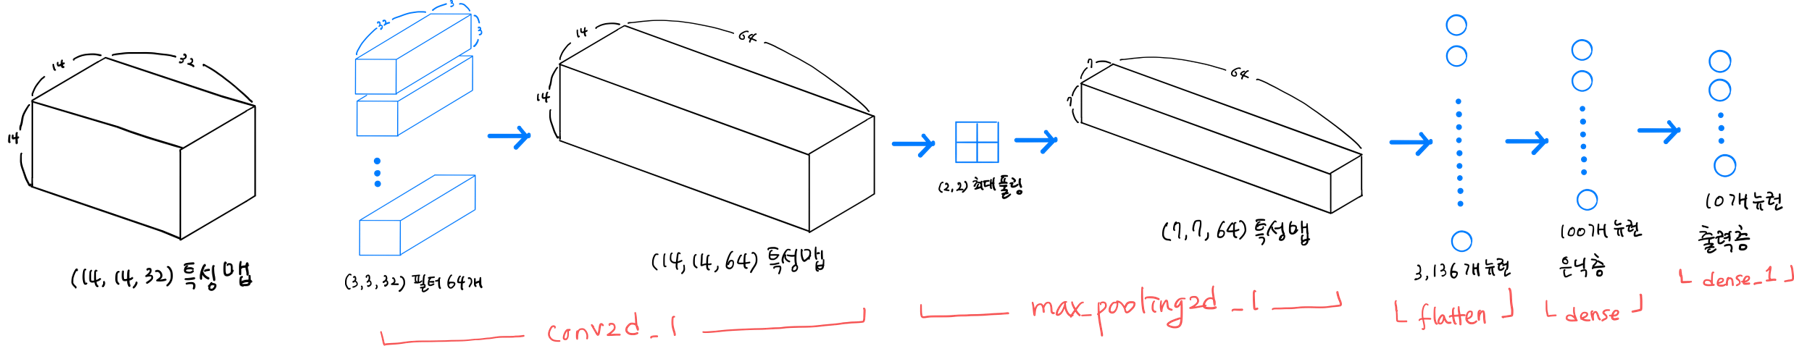

In [ ]:
# 3차원 특성 맵을 일렬로 펼칠 차례임
# -> 마지막에 10 개의 뉴런을 가진 밀집 층에서 확률을 계산
# 이번에는 특성맵을 일렬로 펼쳐서 바로 출력층에 전달하지 않고
# 중간에 하나의 밀집 은닉층을 하나 추가함
# Flatten -> Dense 은닉층 -> Dropout -> Dense 출력층

model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100,activation='relu'))
# 은닉층은 100개의 뉴런을 사용하고 활성화 함수는 합성곱과 같은 렐루 사용

model.add(keras.layers.Dropout(0.4))
# 드롭아웃을 이용해 은닉층의 과대적합을 막아 성능을 조금 개선

model.add(keras.layers.Dense(10, activation='softmax'))
# 패션 M?NIIST는 클래스를 10개로 분류하는 다중 분류 문제임으로 활성화 함수는 소프트 맥스 사용
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 합성곱 층과 풀링 층의 효과를 확인할수 있다.
# 첫번째 합성곱 층을 통과하면서 특성 맵의 깊이는 32가 됨
# 두번째 합성곱 층을 통과하면서 특성 맵의 크기가 64로 늘어남
# 반명 특성 맵의 가로 세로 크기는 첫번째 풀링 층에서 절반으로 줄어들고
# 두번째 풀링에서 다시 절반으로 줄어듬 따라서 최종 특성 맵의 크기는 (7,7,64)임

# 완젼 신경망에서 했던 것 처럼 모델 파라미터 개수는 첫번째 합성곱 층은
# 32개의 필터를 가지고 있고 크기가(3,3,)깊이가 1이고 필터마다 1의 절편아 있음
# 3*3*1*32+32=320 의 파라미터

# 두번째 합성곱 층은 64개의 필터를 사용하게 크기가(3,3,,)
# 깊이가 32이고 필터마다 1의 절편이 있음
# 3*3*32*64*+64 = 18496의 파라미터

# Flatten 클래스의 (7,7,64) 크기의 특성 맵을 1차원 배열로 펼치면
# (3136,)의 크기의 배열이 됨 이를 100개의 뉴런과 완전히 연결해야 함으로
# 은닉층의 모델 파라미터 개수 -> 3316* 100 + 100 = 313700의 파라미터

# 마지막 출력층의 모델 파라미터 개수는 1010개

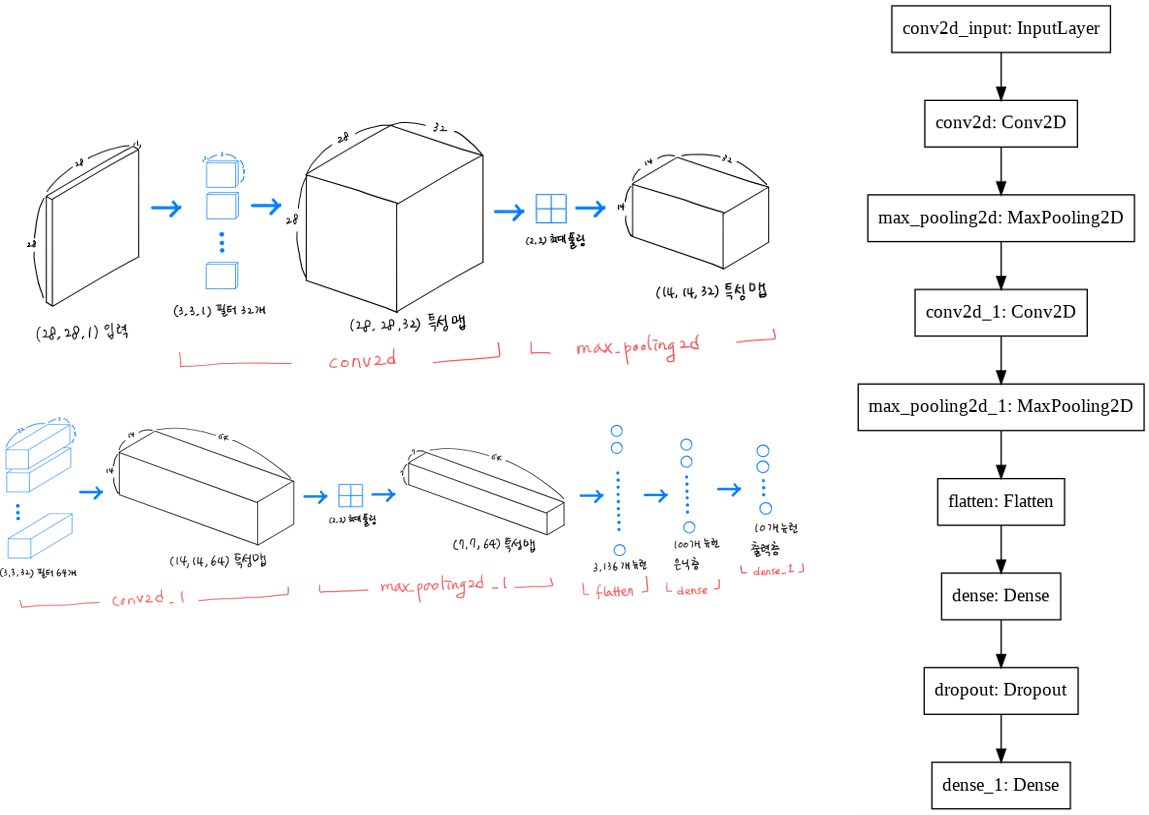

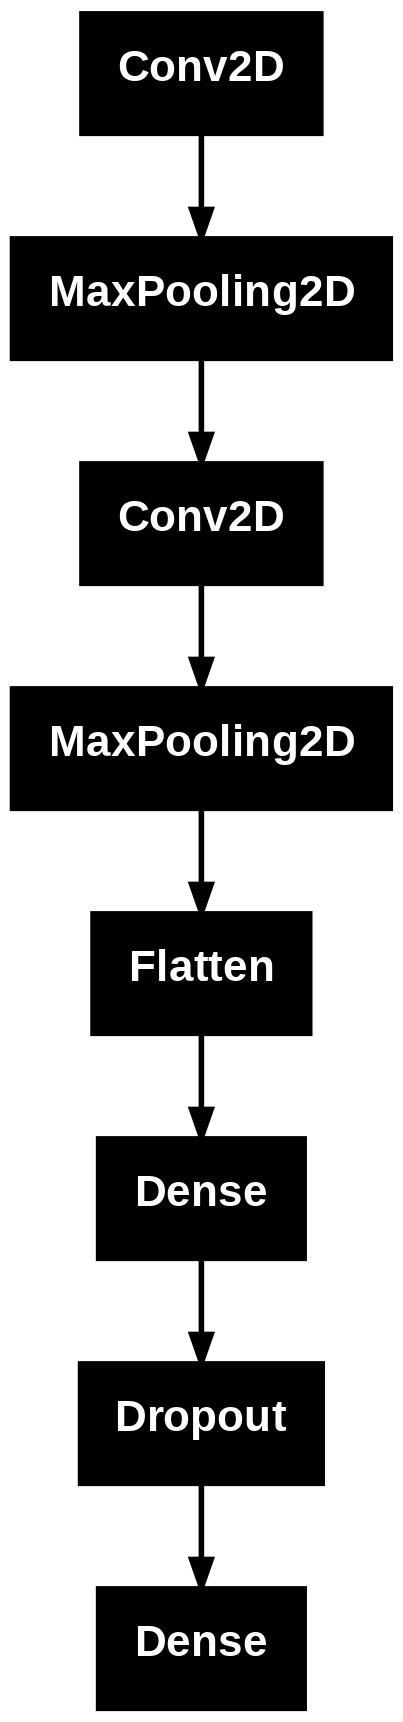

In [ ]:
# 케라스는 층의 구성을 보여주는 메서드가 있다.(keras.utils.plot_model)
keras.utils.plot_model(model) # 버전차이

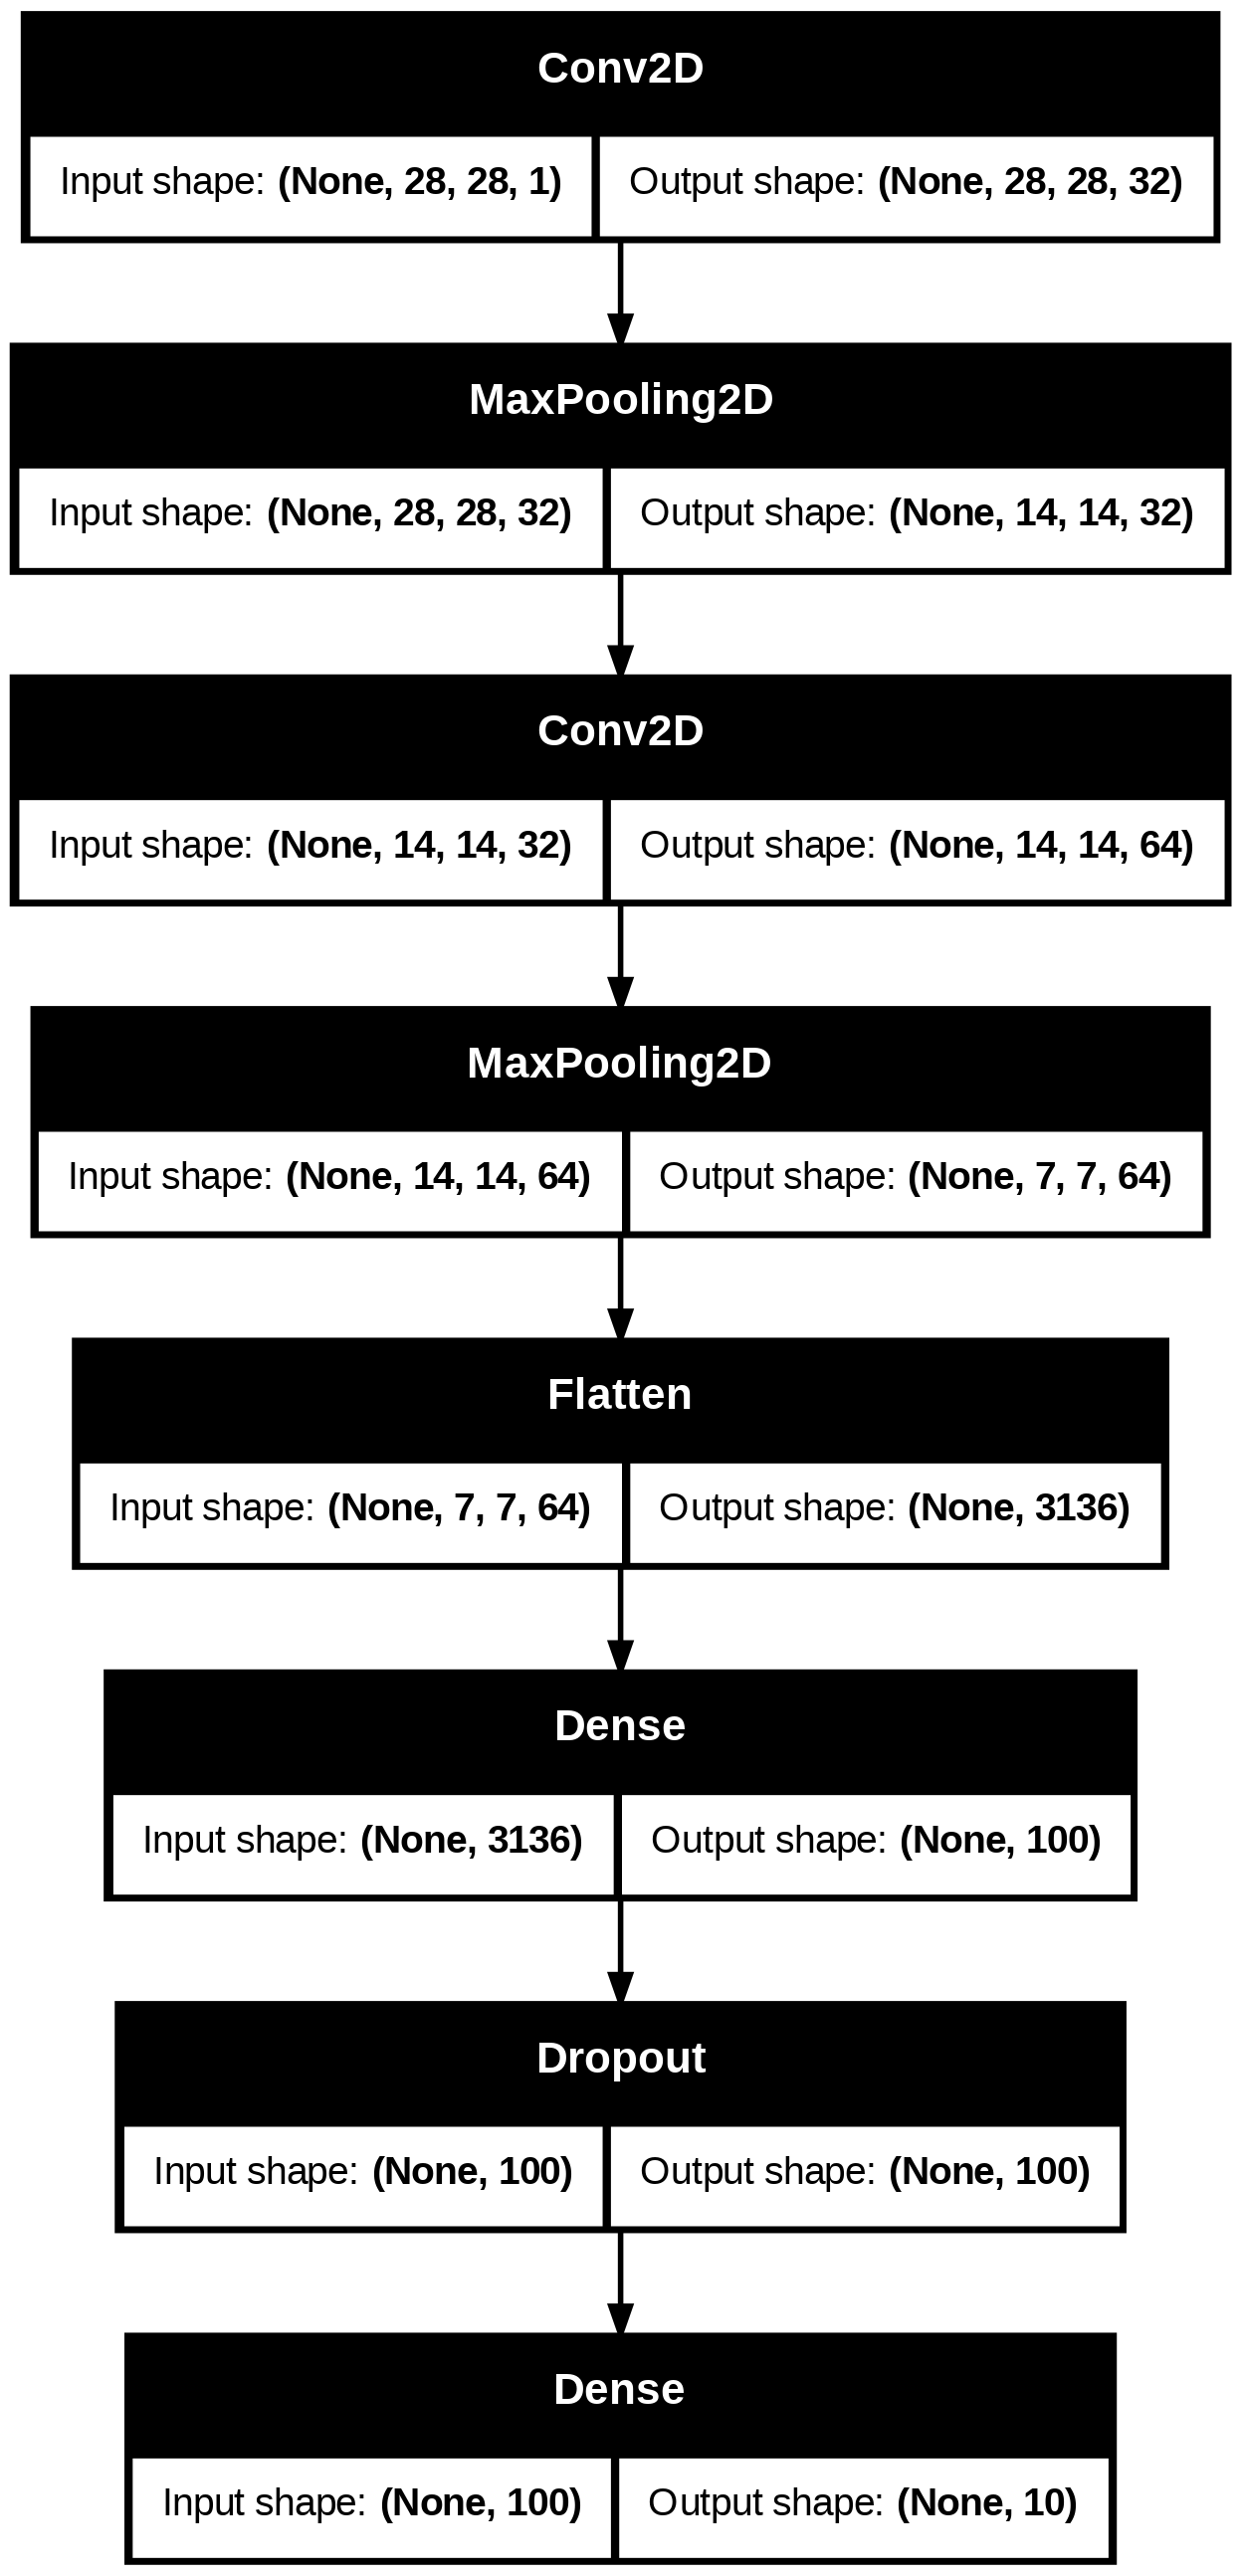

In [ ]:
keras.utils.plot_model(model, show_shapes=True) # 입력과 출력의 크기를 표시

In [ ]:
# 패션 MNIST 데이터에 적용할 합성곱 신경망 모델의 구성 끝 -> 컴파일 하고 훈련 진행 시작!

# 모델 컴파일과 훈련
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# 아담 최적화로 훈련

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.keras', save_best_only=True)
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.keras', save_best_only=True)
# modelCheckpoint 콜백 조기 종료 -> 검증이 2번 정도 상향 시 조기 종료

early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
# EarlyStoppin 콜백 조기 종료
history = model.fit(train_scaled, train_target, epochs=20,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb]) ## 11분걸림


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.6956 - loss: 0.8261 - val_accuracy: 0.8673 - val_loss: 0.3756
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8514 - loss: 0.4123 - val_accuracy: 0.8855 - val_loss: 0.3061
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8719 - loss: 0.3534 - val_accuracy: 0.8935 - val_loss: 0.2825
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8854 - loss: 0.3132 - val_accuracy: 0.9003 - val_loss: 0.2602
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8930 - loss: 0.2909 - val_accuracy: 0.9043 - val_loss: 0.2557
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9011 - loss: 0.2670 - val_accuracy: 0.9091 - val_loss: 0.2421
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9090 - loss: 0.2495 - val_accuracy: 0.9147 - val_loss: 0.2329
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9135 - loss: 0.2342 -

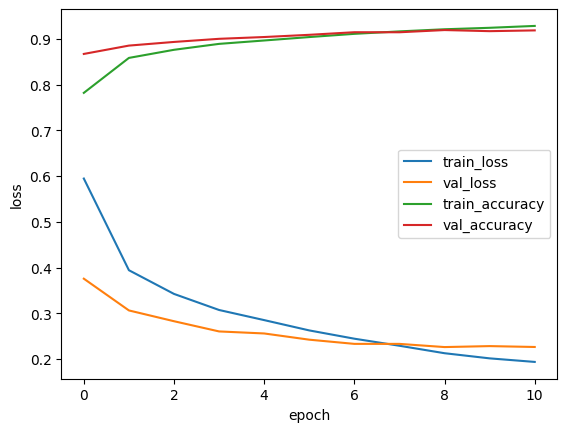

In [ ]:
# 훈련 세트 성능이 93.39% 까지 나왔음
# 손실 그래프를 그려서 조기 종료가 잘 이루어 졌는지 확인해 보자

import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train_loss', 'val_loss', 'train_accuracy', 'val_accuracy'])
plt.show()
# 검증 세트에 대한 손실이 점차 감소하다 정체되기 시작하고
# 훈련 세트에 대한 손실은 점점 낮아짐
# 이 그래프를 기반으로 8번째 에포크를 최적으로 생각할수 있음
# 결과는 학생마다 다를수 있음


In [ ]:
# EarltStopping 클래스에서 restore_best_weights=True로 지정해서
# 현재 model 객체가 최적의 모델 파라미터로 복원됨
# ModelCheckpoint 콜백이 저장한 best-cnn-model.keras 파일을 다시 읽을 필요가 없음

# 이번 세트에 대한 성능 평가 진행
model.evaluate(val_scaled, val_target)
# 이 결과는 fit() 메서드 출력 중 다섯번째 모델 파라미터로 잘 복원 함

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9220 - loss: 0.2179


[0.2259405106306076, 0.9194999933242798]

In [ ]:
# 맨처음 떼어 놓았던 테스트 세트로 합성곱 신경망의 일반화 성능을 파악해보자.
test_scaled = test_input.reshape(-1, 28, 28, 1)/ 255.0
# 훈련 세트와 검증 세트에서 했던 것 처럼 픽셀 값의 범위를
# 0~1 사이로 바꾸고 이미지 크기를 (28,28,1)로 변경

model.evaluate(test_scaled, test_target)
# 테스트 세트에서 점수는 검증 세트보다 조금 작음
# 이 모델을 실전에 투입하면 90% 이상의 성능을 기대할수 있음

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8935 - loss: 0.6552


[0.630507230758667, 0.8931000232696533]

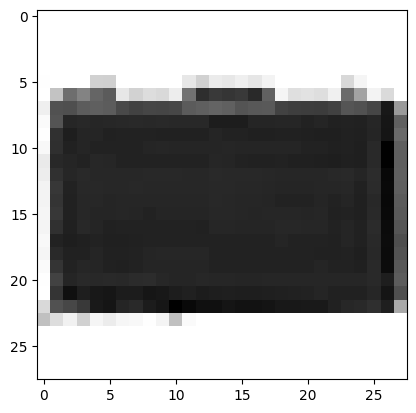

In [ ]:
# 편의상 검증 세트의 첫 번째 샘플인 이미지를 활용해 보자
# 맥플롯립에서 흑백 이미지에 깊이 차원은 없다
# -> (28,28,1) 크기를 (28,28)로 변경 reshape(28,28)
plt.imshow(val_scaled[39].reshape(28,28), cmap='gray_r')
# 첫 번째 샘플인 val_scaled[39]

plt.show() # 검증용 리스트의 39번에 있는 이미지를 출력하였다.

In [ ]:
# 확률 예측 시도 predict() 메서드는 10 개의 클래스에 대한  예측 확률을 출력

preds = model.predict(val_scaled[39:40])
print(preds)
# 결과를 보면 9번째 값이 1로 판단되고 나머지는 지수형식으로 나왔는데
# e- 가 있으면 마이너스 임(0에 가까움)

# 5e3 -> 5x10^3
# 5e-3 -> 5x10^-3
# [[3.0354818e-16 2.0498499e-21 4.4698989e-19 1.5067686e-19 7.0234020e-18
#   8.2857021e-17 4.4651635e-18 6.6868857e-19 1.0000000e+00 1.9831414e-20]]
# ['티셔츠',     '바지',       '스웨터',      '드레스',     '코트',
#  '샌달',       '셔츠',       '스니커즈',    '가방',       '앵클 부츠']


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 678ms/step
[[6.3776392e-06 9.5649155e-10 1.2333817e-07 6.0282151e-10 1.7307210e-09
  1.3358177e-08 3.0454146e-07 3.3454782e-08 9.9999309e-01 2.9446356e-08]]


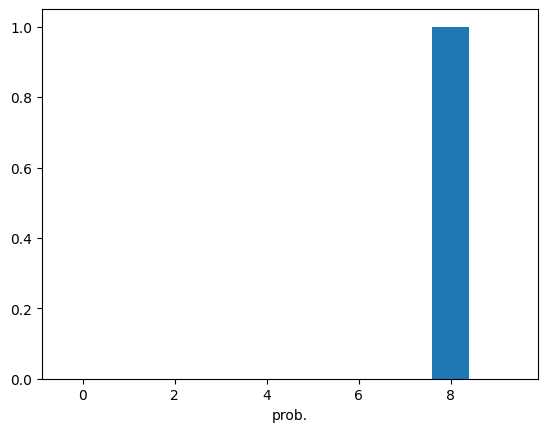

In [ ]:
# 막대 그래프로 표시
plt.bar(range(0,10), preds[0])
plt.xlabel('class')
plt.xlabel('prob.')
plt.show()
# 티셔츠 바지 스웨터 드레스 코트 샌달 셔츠 스니커즈 가방 앵클부츠
#   0     1     2     3     4     5    6    7        8    9


In [ ]:
classes = ['티셔츠', '바지', '스웨터', '드레스', '코드', '샌달', '스니커즈', '가방', '앵클부츠']
# 레이블 추가

In [ ]:
import numpy as np
print(classes[np.argmax(preds)])
# 가방 예측 성공 타깃에 true 값이 연결되서 값이 나옴

앵클부츠
